# 📊 Évaluation comparative des modèles MIL — Classification binaire
Évalue **ABMIL**, **AttentionMIL_Papagoras** et **MILMaxPooling** sur le même jeu de test.
Features pré-extraites par **UNI2** (dim 1536), format `.h5`.

## 0 · Configuration

In [1]:
import os, glob, re
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from typing import Tuple
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from models.abmil import ABMIL,GatedAttention
from models.attention_mil import AttentionMIL_Papagoras
from models.mil_max_pooling import MILMaxPooling
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef,
    confusion_matrix, roc_curve, precision_recall_curve,
    classification_report
)
from sklearn.calibration import calibration_curve

# ── Paramètres ────────────────────────────────────────────────────────────
MODELS_DIR    = '../outputs/models_to_eval/'           # dossier contenant les .pt / .pth
TEST_DATA_DIR = 'C:/Users/manon/Documents/pathology_MIL/data/CHU_UNI2_embeds/HE/test'    # features .h5 par slide
LABELS_CSV    = '../data/splits_chu/test.csv'  # colonnes : slide_id, label (0/1)
OUTPUT_DIR    = './eval_outputs'

DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
INPUT_DIM     = 1536   # UNI2
HIDDEN_DIM    = 256
N_CLASSES     = 2
CLASS_NAMES   = ['Negatif', 'Positif']

# cle des features dans les .h5 — adapter si different ('feats', 'x', ...)
H5_FEAT_KEY   = 'embeddings'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Device  : {DEVICE}')
print(f'Modeles : {MODELS_DIR}')

Device  : cuda
Modeles : ../outputs/models_to_eval/


## 1 · Architectures

In [2]:

# ── Registre : pattern → (classe, kwargs) ────────────────────────────────
# Ordre important : patterns plus specifiques en premier
MODEL_REGISTRY = [
    (r'attention_mil', AttentionMIL_Papagoras, dict(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, n_classes=1)),
    (r'mil_max',       MILMaxPooling,          dict(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM)),
    (r'abmil',         ABMIL,                  dict(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, n_classes=N_CLASSES)),
]

# Autorise la deserialisation PyTorch 2.6+
torch.serialization.add_safe_globals([ABMIL, AttentionMIL_Papagoras, MILMaxPooling, GatedAttention])

def get_architecture(model_name):
    name_lower = model_name.lower()
    for pattern, cls, kwargs in MODEL_REGISTRY:
        if re.search(pattern, name_lower):
            return cls, kwargs
    raise ValueError(f'Aucune architecture pour : {model_name}')

print('Architectures :', [p for p, *_ in MODEL_REGISTRY])

Architectures : ['attention_mil', 'mil_max', 'abmil']


## 2 · Dataset

In [3]:
class H5Dataset(Dataset):
    def __init__(self, dataframe, embeddings_dir):
        self.embeddings_dir = embeddings_dir
        self.df = self._filter_existing(dataframe)

    def _filter_existing(self, dataframe):
        mask = dataframe["slide_id"].apply(
            lambda sid: Path(self.embeddings_dir, f"{sid}.h5").exists()
        )
        missing_ids = dataframe.loc[~mask, "slide_id"].tolist()
        if missing_ids:
            print(f"[H5Dataset] {len(missing_ids)} file(s) .h5 cannot be found - ignored :")
            for sid in missing_ids:
                print(f"  - {sid}.h5")
        return dataframe[mask].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with h5py.File(Path(self.embeddings_dir, f"{row.slide_id}.h5"), "r") as f:
            if "features" in f:
                hes = f["features"][:]
            elif "embeddings" in f:
                hes = f["embeddings"][:]
            else:
                raise KeyError("Neither 'features' nor 'embeddings' found in file")

        hes   = torch.tensor(hes, dtype=torch.float32)
        label = torch.tensor(row.label, dtype=torch.float32)

        return hes, label
# Cellule 2 — Dataset et loader
df_test = pd.read_csv(LABELS_CSV)
dataset = H5Dataset(df_test, TEST_DATA_DIR)

def collate_fn(batch):
    feats, label = batch[0]
    return feats, label.item()

loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

print(f'Slides de test : {len(dataset)}')
print(df_test['label'].value_counts()
      .rename(index={0: CLASS_NAMES[0], 1: CLASS_NAMES[1]}))

[H5Dataset] 1 file(s) .h5 cannot be found - ignored :
  - 25P18616.h5
Slides de test : 14
label
Positif    12
Negatif     3
Name: count, dtype: int64


## 3 · Chargement et inférence

In [4]:
def load_model(ckpt_path, device):
    name        = Path(ckpt_path).stem
    cls, kwargs = get_architecture(name)
    model       = cls(**kwargs)

    # chargement robuste PyTorch 2.6+
    try:
        raw = torch.load(ckpt_path, map_location=device, weights_only=True)
    except Exception as e:
        if 'WeightsUnpickler' in str(e) or 'Unsupported global' in str(e):
            raw = torch.load(ckpt_path, map_location=device, weights_only=False)
        else:
            raise

    # extraction du state_dict
    if isinstance(raw, nn.Module):
        state = raw.state_dict()
    elif isinstance(raw, dict):
        state = raw
        for key in ('model_state_dict', 'state_dict', 'model', 'net'):
            if key in raw:
                candidate = raw[key]
                state = candidate.state_dict() if isinstance(candidate, nn.Module) else candidate
                break
    else:
        raise TypeError(f'Format de checkpoint non reconnu : {type(raw)}')

    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing:     print(f'   cles manquantes  ({len(missing)}) : {missing[:3]}')
    if unexpected:  print(f'   cles inattendues ({len(unexpected)}) : {unexpected[:3]}')

    model.to(device).eval()
    is_max_pool = isinstance(model, MILMaxPooling)
    return model, is_max_pool


# run_inference adapté — 2 valeurs uniquement
@torch.no_grad()
def run_inference(model, loader, device, is_max_pool):
    y_true, y_prob, y_pred = [], [], []

    for feats, label in tqdm(loader, desc='Inference'):
        feats = feats.to(device)   # [N, 1536]

        out       = model(feats)
        logits    = out[0] if isinstance(out, (tuple, list)) else out
        logits_sq = logits.squeeze()

        if logits_sq.ndim == 0 or logits_sq.shape[-1] == 1:
            prob_pos = torch.sigmoid(logits_sq).item()
            pred     = int(prob_pos >= 0.5)
        else:
            probs    = torch.softmax(logits_sq, dim=-1).cpu().numpy()
            prob_pos = float(probs[1])
            pred     = int(probs.argmax())

        y_true.append(int(label))
        y_prob.append(prob_pos)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_prob), np.array(y_pred)


# ── Scan et inference ─────────────────────────────────────────────────────
ckpt_paths = sorted(
    glob.glob(os.path.join(MODELS_DIR, '*.pt')) +
    glob.glob(os.path.join(MODELS_DIR, '*.pth'))
)
if not ckpt_paths:
    raise RuntimeError(f'Aucun checkpoint trouve dans {MODELS_DIR}')

print(f'{len(ckpt_paths)} modele(s) :')
for p in ckpt_paths:
    print(f'  {p}')

results = {}

for ckpt in ckpt_paths:
    model_name = Path(ckpt).stem
    print(f'\n>> {model_name} ...')
    try:
        model, is_max_pool = load_model(ckpt, DEVICE)
        y_true, y_prob, y_pred = run_inference(model, loader, DEVICE, is_max_pool)
        results[model_name] = {
            'y_true':      y_true,
            'y_prob':      y_prob,
            'y_pred':      y_pred,
            'is_max_pool': is_max_pool,
        }
        auc = roc_auc_score(y_true, y_prob)
        acc = accuracy_score(y_true, y_pred)
        print(f'   OK  acc={acc:.3f}  auc={auc:.3f}  slides={len(y_true)}')
    except Exception as e:
        print(f'   ERREUR : {e}')

9 modele(s) :
  ../outputs/models_to_eval\abmil_chu_0_1e-3.pt
  ../outputs/models_to_eval\abmil_chu_1e-4.pt
  ../outputs/models_to_eval\abmil_chu_5e-05.pt
  ../outputs/models_to_eval\attention_mil_chu_1e-3.pt
  ../outputs/models_to_eval\attention_mil_chu_1e-4.pt
  ../outputs/models_to_eval\attention_mil_chu_5e-05.pt
  ../outputs/models_to_eval\mil_max_chu_1e-3.pt
  ../outputs/models_to_eval\mil_max_chu_1e-4.pt
  ../outputs/models_to_eval\mil_max_chu_5e-05.pt

>> abmil_chu_0_1e-3 ...
   cles manquantes  (11) : ['attention.feature_proj.0.weight', 'attention.feature_proj.0.bias', 'attention.attention_V.0.weight']
   cles inattendues (6) : ['encoder.0.weight', 'encoder.0.bias', 'encoder.2.weight']


Inference: 100%|██████████| 14/14 [00:03<00:00,  4.31it/s]


   OK  acc=0.714  auc=0.303  slides=14

>> abmil_chu_1e-4 ...
   cles manquantes  (11) : ['attention.feature_proj.0.weight', 'attention.feature_proj.0.bias', 'attention.attention_V.0.weight']
   cles inattendues (6) : ['encoder.0.weight', 'encoder.0.bias', 'encoder.2.weight']


Inference: 100%|██████████| 14/14 [00:02<00:00,  6.24it/s]


   OK  acc=0.786  auc=0.576  slides=14

>> abmil_chu_5e-05 ...
   cles manquantes  (11) : ['attention.feature_proj.0.weight', 'attention.feature_proj.0.bias', 'attention.attention_V.0.weight']
   cles inattendues (6) : ['encoder.0.weight', 'encoder.0.bias', 'encoder.2.weight']


...

   OK  acc=0.929  auc=0.879  slides=14

>> mil_max_chu_1e-4 ...


Inference: 100%|██████████| 14/14 [00:02<00:00,  5.45it/s]


   OK  acc=0.929  auc=0.939  slides=14

>> mil_max_chu_5e-05 ...


Inference: 100%|██████████| 14/14 [00:02<00:00,  5.13it/s]

   OK  acc=0.857  auc=0.909  slides=14


## 4 · Metriques

In [5]:
def safe(fn, *args):
    try:
        return round(fn(*args), 4)
    except Exception:
        return float('nan')

rows = []
for model_name, res in results.items():
    yt, yp, ypr = res['y_true'], res['y_pred'], res['y_prob']
    cm = confusion_matrix(yt, yp, normalize='true')
    rows.append({
        'Modele':         model_name,
        'Accuracy':       safe(accuracy_score, yt, yp),
        'Balanced Acc.':  safe(balanced_accuracy_score, yt, yp),
        'AUC-ROC':        safe(roc_auc_score, yt, ypr),
        'AUC-PR':         safe(average_precision_score, yt, ypr),
        'F1':             safe(f1_score, yt, yp),
        'MCC':            safe(matthews_corrcoef, yt, yp),
        'Sensibilite':    round(float(cm[1, 1]), 4) if cm.shape == (2,2) else float('nan'),
        'Specificite':    round(float(cm[0, 0]), 4) if cm.shape == (2,2) else float('nan'),
    })

df_metrics = pd.DataFrame(rows).set_index('Modele')
df_metrics.to_csv(os.path.join(OUTPUT_DIR, 'metrics_summary.csv'))

display(
    df_metrics.style
    .background_gradient(cmap='RdYlGn', axis=0)
    .format('{:.4f}')
    .set_caption('Metriques — jeu de test')
)

,Accuracy,Balanced Acc.,AUC-ROC,AUC-PR,F1,MCC,Sensibilite,Specificite
Modele,,,,,,,,
abmil_chu_0_1e-3,0.7143,0.4545,0.3030,0.7694,0.8333,-0.1448,0.9091,0.0000
abmil_chu_1e-4,0.7857,0.5000,0.5758,0.8791,0.8800,0.0000,1.0000,0.0000
abmil_chu_5e-05,0.7857,0.5000,0.9394,0.9842,0.8800,0.0000,1.0000,0.0000
attention_mil_chu_1e-3,0.2143,0.5000,0.8788,0.9709,0.0000,0.0000,0.0000,1.0000
attention_mil_chu_1e-4,0.5714,0.7273,0.9091,0.9751,0.6250,0.3892,0.4545,1.0000
attention_mil_chu_5e-05,0.2143,0.5000,0.3333,0.7264,0.0000,0.0000,0.0000,1.0000
mil_max_chu_1e-3,0.9286,0.8333,0.8788,0.9650,0.9565,0.7817,1.0000,0.6667
mil_max_chu_1e-4,0.9286,0.8333,0.9394,0.9842,0.9565,0.7817,1.0000,0.6667
mil_max_chu_5e-05,0.8571,0.6667,0.9091,0.9751,0.9167,0.5311,1.0000,0.3333


## 5 · Graphiques

In [6]:
COLORS = sns.color_palette('tab10', n_colors=max(len(results), 1))
MODEL_COLORS = {name: COLORS[i] for i, name in enumerate(results)}
sns.set_theme(style='whitegrid', font_scale=1.05)

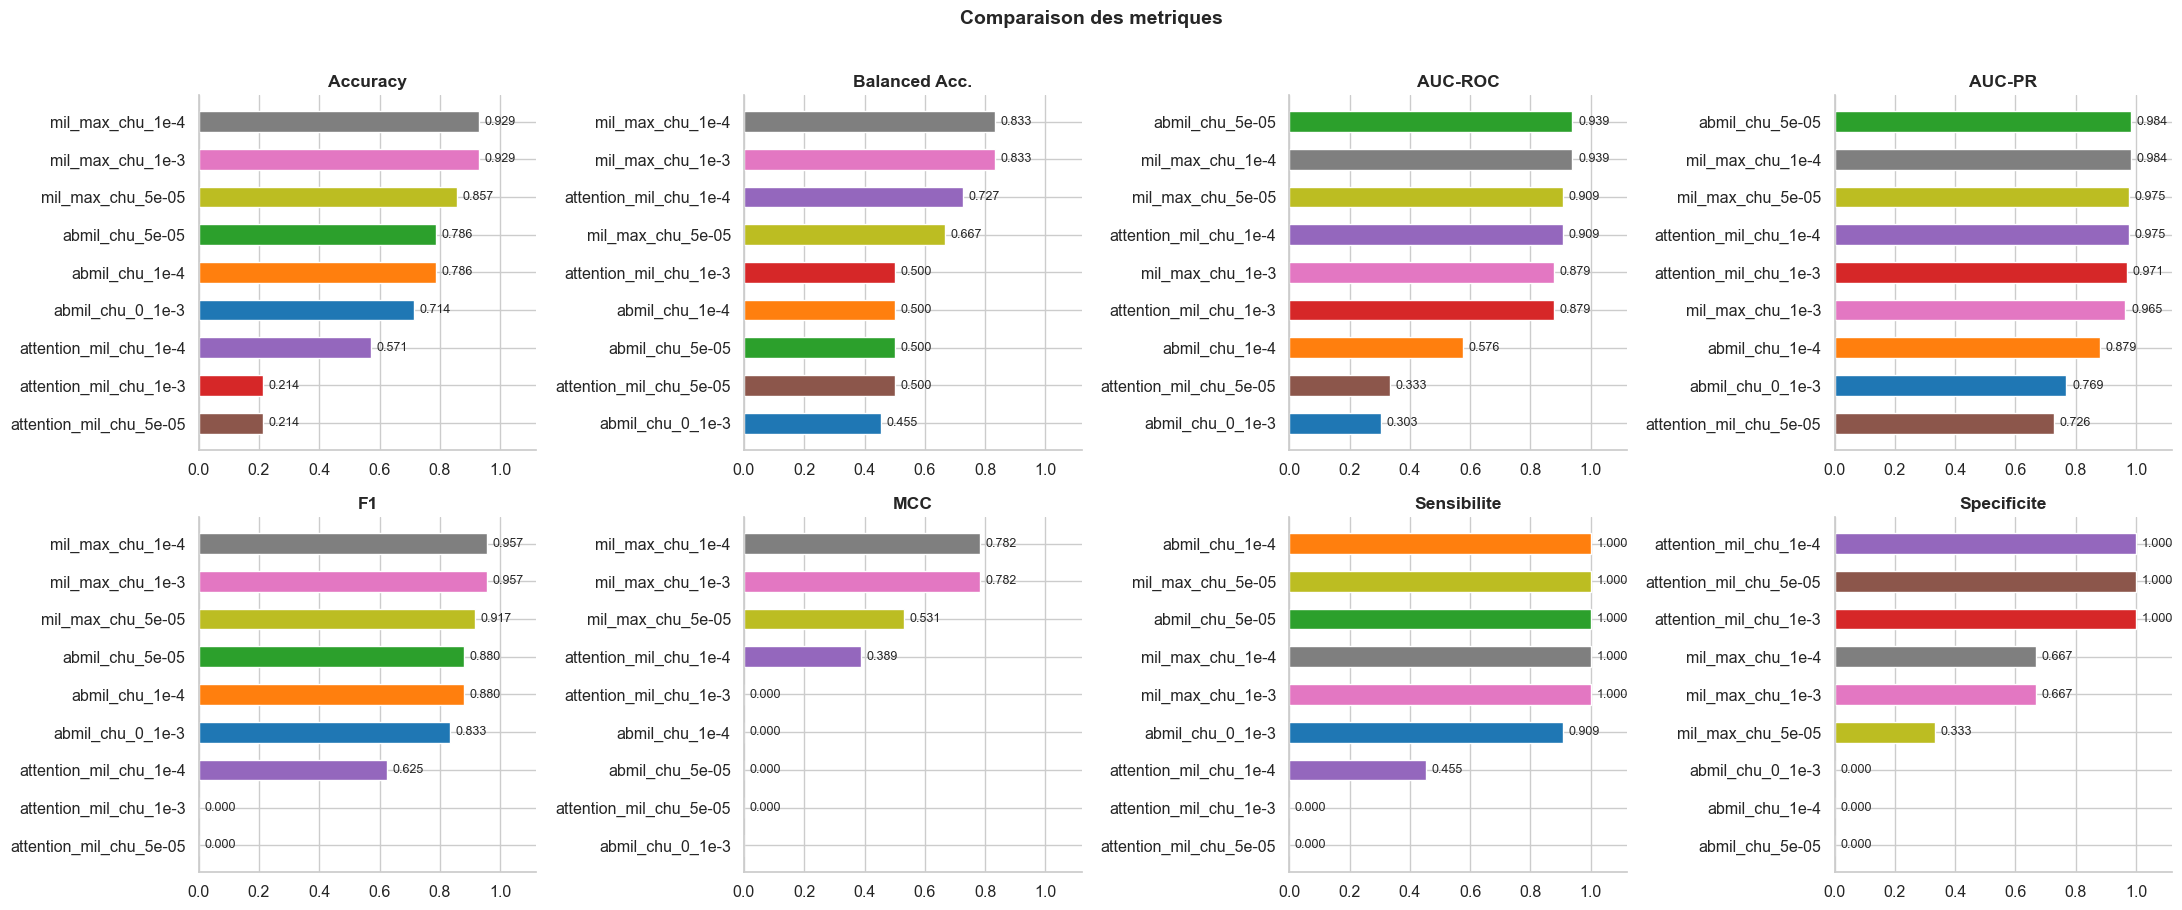

In [7]:
# ── 5.1  Barplot metriques ────────────────────────────────────────────────
metrics_cols = df_metrics.columns.tolist()
ncols = 4
nrows = (len(metrics_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows))
axes = np.array(axes).flatten()

for ax, metric in zip(axes, metrics_cols):
    vals   = df_metrics[metric].dropna().sort_values(ascending=False)
    colors = [MODEL_COLORS[m] for m in vals.index]
    bars   = ax.barh(vals.index, vals.values, color=colors,
                     edgecolor='white', height=0.55)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0, 1.12)
    ax.invert_yaxis()
    ax.spines[['top','right']].set_visible(False)

for ax in axes[len(metrics_cols):]:
    ax.set_visible(False)

plt.suptitle('Comparaison des metriques', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_01_metrics_barplot.png'), bbox_inches='tight', dpi=150)
plt.show()

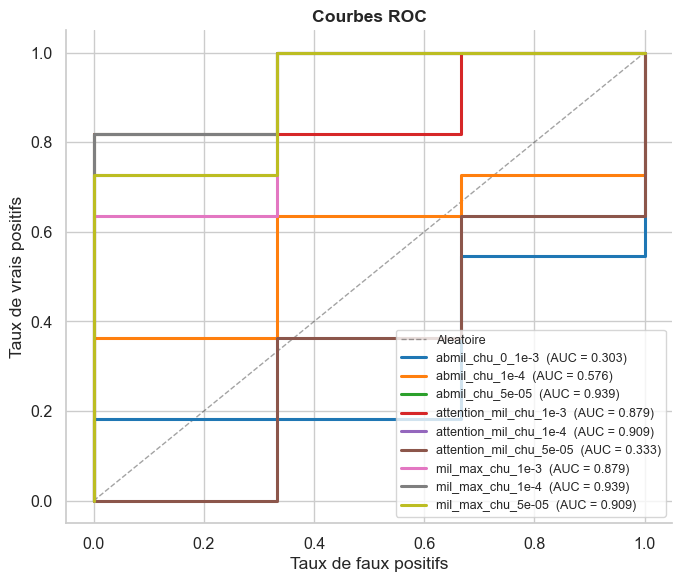

In [8]:
# ── 5.2  Courbes ROC ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1], 'k--', alpha=0.4, lw=1, label='Aleatoire')

for model_name, res in results.items():
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
    auc = roc_auc_score(res['y_true'], res['y_prob'])
    ax.plot(fpr, tpr, color=MODEL_COLORS[model_name],
            lw=2.2, label=f"{model_name}  (AUC = {auc:.3f})")

ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbes ROC', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_02_roc_curves.png'), bbox_inches='tight', dpi=150)
plt.show()

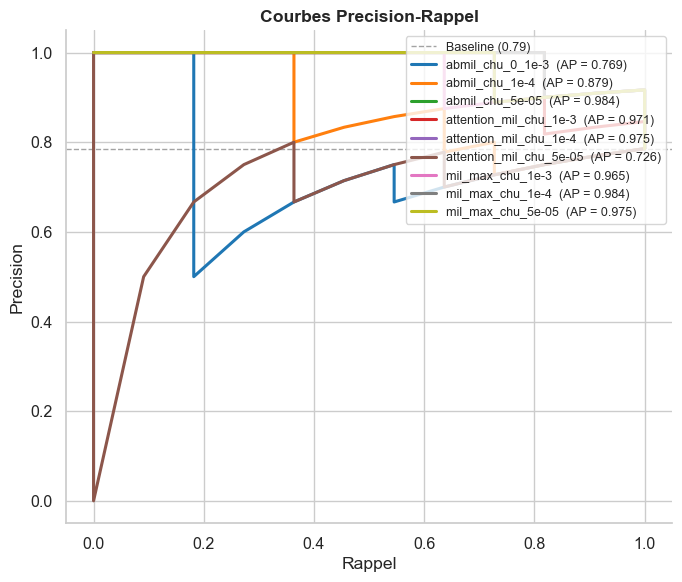

In [9]:
# ── 5.3  Courbes Precision-Rappel ─────────────────────────────────────────
baseline = next(iter(results.values()))['y_true'].mean()

fig, ax = plt.subplots(figsize=(7, 6))
ax.axhline(baseline, color='k', ls='--', alpha=0.4, lw=1,
           label=f'Baseline ({baseline:.2f})')

for model_name, res in results.items():
    prec, rec, _ = precision_recall_curve(res['y_true'], res['y_prob'])
    ap = average_precision_score(res['y_true'], res['y_prob'])
    ax.plot(rec, prec, color=MODEL_COLORS[model_name],
            lw=2.2, label=f"{model_name}  (AP = {ap:.3f})")

ax.set_xlabel('Rappel')
ax.set_ylabel('Precision')
ax.set_title('Courbes Precision-Rappel', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_03_pr_curves.png'), bbox_inches='tight', dpi=150)
plt.show()

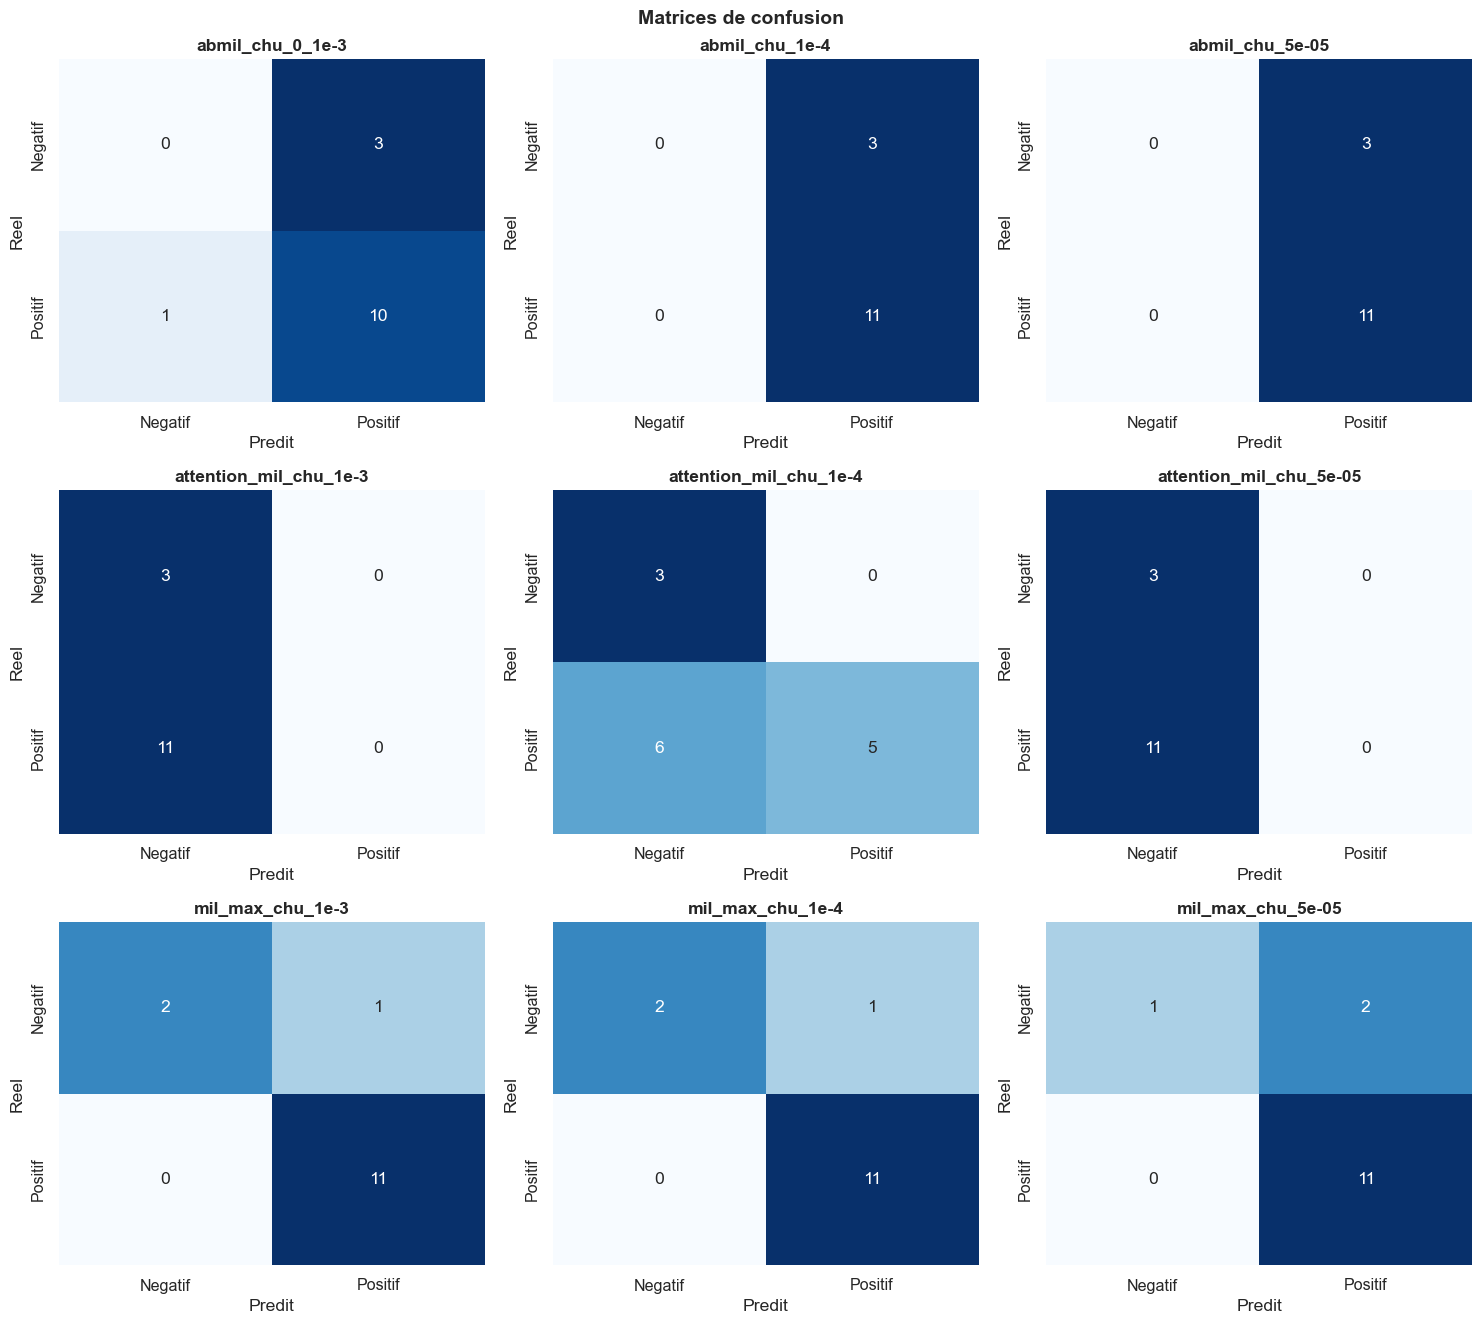

In [10]:
# ── 5.4  Matrices de confusion ────────────────────────────────────────────
n_models = len(results)
ncols    = min(3, n_models)
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
axes = np.array(axes).reshape(nrows, ncols)

for idx, (model_name, res) in enumerate(results.items()):
    ax  = axes[idx // ncols, idx % ncols]
    cm  = confusion_matrix(res['y_true'], res['y_pred'])
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, annot=cm, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel('Predit')
    ax.set_ylabel('Reel')

for idx in range(n_models, nrows*ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.suptitle('Matrices de confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_04_confusion_matrices.png'), bbox_inches='tight', dpi=150)
plt.show()

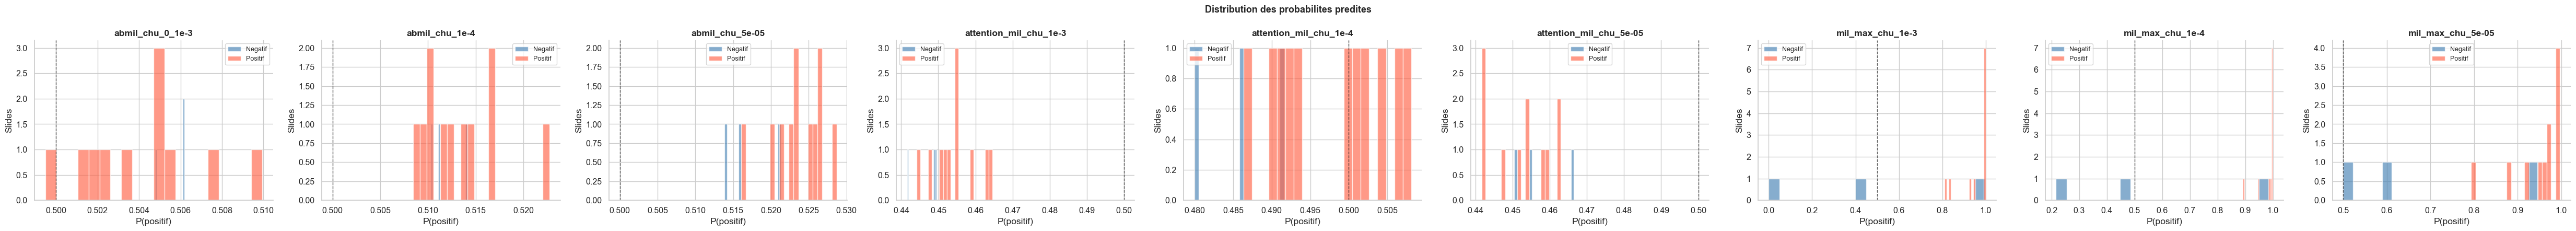

In [11]:
# ── 5.5  Distribution des probabilites predites ───────────────────────────
fig, axes = plt.subplots(1, n_models, figsize=(5.5*n_models, 4.5), sharey=False)
if n_models == 1:
    axes = [axes]

for ax, (model_name, res) in zip(axes, results.items()):
    for lbl, lname, color in zip([0, 1], CLASS_NAMES, ['steelblue', 'tomato']):
        mask = res['y_true'] == lbl
        ax.hist(res['y_prob'][mask], bins=20, alpha=0.65,
                label=lname, color=color, edgecolor='white')
    ax.axvline(0.5, color='k', ls='--', lw=1, alpha=0.7)
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel('P(positif)')
    ax.set_ylabel('Slides')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Distribution des probabilites predites', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_05_prob_distributions.png'), bbox_inches='tight', dpi=150)
plt.show()

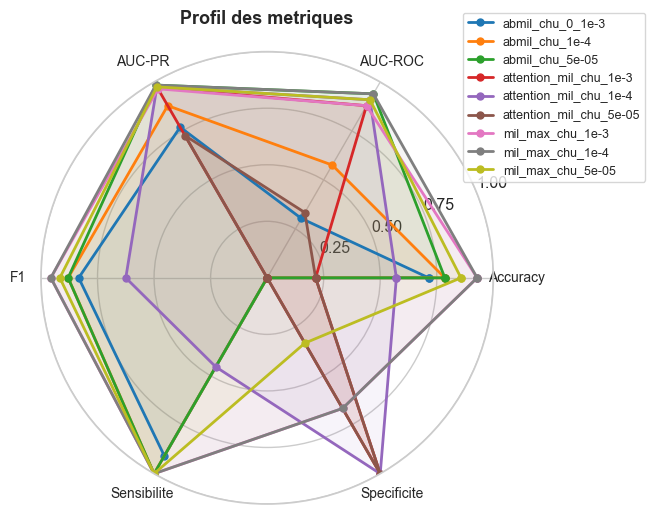

In [12]:
# ── 5.6  Radar chart ──────────────────────────────────────────────────────
radar_metrics = ['Accuracy', 'AUC-ROC', 'AUC-PR', 'F1', 'Sensibilite', 'Specificite']
N      = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model_name in results:
    values = [df_metrics.loc[model_name, m] for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, '-o', color=MODEL_COLORS[model_name],
            lw=2, ms=5, label=model_name)
    ax.fill(angles, values, alpha=0.07, color=MODEL_COLORS[model_name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_title('Profil des metriques', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_06_radar.png'), bbox_inches='tight', dpi=150)
plt.show()

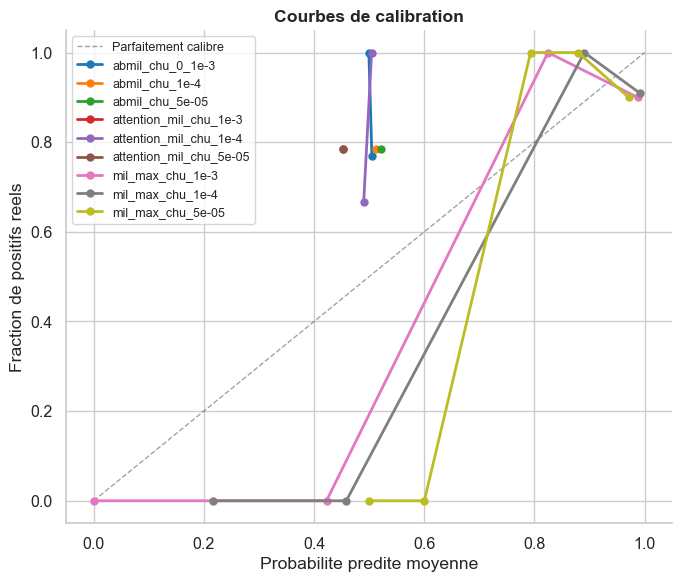

In [13]:
# ── 5.7  Calibration ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1], 'k--', alpha=0.4, lw=1, label='Parfaitement calibre')

for model_name, res in results.items():
    try:
        frac_pos, mean_pred = calibration_curve(
            res['y_true'], res['y_prob'], n_bins=10, strategy='uniform'
        )
        ax.plot(mean_pred, frac_pos, '-o', ms=5,
                color=MODEL_COLORS[model_name], lw=2, label=model_name)
    except Exception:
        pass

ax.set_xlabel('Probabilite predite moyenne')
ax.set_ylabel('Fraction de positifs reels')
ax.set_title('Courbes de calibration', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_07_calibration.png'), bbox_inches='tight', dpi=150)
plt.show()

## 6 · Rapport final

In [14]:
print('=' * 65)
print('RAPPORT DE SYNTHESE')
print('=' * 65)

for model_name, res in results.items():
    arch = 'MILMaxPooling' if res['is_max_pool'] else 'Attention MIL'
    print(f'\n>> {model_name}  [{arch}]')
    print(classification_report(
        res['y_true'], res['y_pred'],
        target_names=CLASS_NAMES, digits=4
    ))

print('\n── Meilleur modele par metrique ──────────────────────────────')
for col in df_metrics.columns:
    best = df_metrics[col].idxmax()
    print(f'  {col:<18} -> {best:<45} ({df_metrics.loc[best, col]:.4f})')

print(f'\nFichiers sauvegardes dans : {os.path.abspath(OUTPUT_DIR)}')

RAPPORT DE SYNTHESE

>> abmil_chu_0_1e-3  [Attention MIL]
              precision    recall  f1-score   support

     Negatif     0.0000    0.0000    0.0000         3
     Positif     0.7692    0.9091    0.8333        11

    accuracy                         0.7143        14
   macro avg     0.3846    0.4545    0.4167        14
weighted avg     0.6044    0.7143    0.6548        14


>> abmil_chu_1e-4  [Attention MIL]
              precision    recall  f1-score   support

     Negatif     0.0000    0.0000    0.0000         3
     Positif     0.7857    1.0000    0.8800        11

    accuracy                         0.7857        14
   macro avg     0.3929    0.5000    0.4400        14
weighted avg     0.6173    0.7857    0.6914        14


>> abmil_chu_5e-05  [Attention MIL]
              precision    recall  f1-score   support

     Negatif     0.0000    0.0000    0.0000         3
     Positif     0.7857    1.0000    0.8800        11

    accuracy                         0.7857        

c:\Users\manon\Documents\pathology_MIL\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manon\Documents\pathology_MIL\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manon\Documents\pathology_MIL\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital